# EECS 6699 Final Project: Reproduce Phases 1-6

This notebook is the top-level reproduction entry point. It keeps the six phase notebooks as the source of each experiment and provides one place to run them in order or inspect the saved outputs.

Default behavior is conservative: long-running cells are disabled until `RUN_EXPERIMENTS` is set to `True`. The saved tables and figures can be reviewed without rerunning training.


## 1. Setup

Run from either the repository root or the `notebooks/` directory.


In [1]:
from pathlib import Path
import csv
import json
import subprocess
import sys

from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


WindowsPath('D:/desktop/6699/EECS6699_Final_Project copy')

In [2]:
import torch

print("python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


python: 3.13.12
torch: 2.12.0+cpu
cuda available: False


## 2. Reproduction Controls

Set `RUN_EXPERIMENTS = True` to execute the phase notebooks. Phase 1 and later phases can take a long time and may overwrite saved result tables, figures, and local model checkpoints.


In [3]:
RUN_EXPERIMENTS = False

PHASE_NOTEBOOKS = [
    "phase1_baseline.ipynb",
    "phase2_input_noise.ipynb",
    "phase3_label_noise.ipynb",
    "phase4_adversarial.ipynb",
    "phase5_lipschitz_regions.ipynb",
    "phase6_complexity_scaling.ipynb",
]

PHASE_NOTEBOOKS


['phase1_baseline.ipynb',
 'phase2_input_noise.ipynb',
 'phase3_label_noise.ipynb',
 'phase4_adversarial.ipynb',
 'phase5_lipschitz_regions.ipynb',
 'phase6_complexity_scaling.ipynb']

## 3. Execute Phase Notebooks

This uses `jupyter nbconvert --execute` through the current Python environment. Outputs are written back into the same notebook files.


In [4]:
def run_notebook(name: str) -> None:
    path = NOTEBOOK_DIR / name
    cmd = [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        "--to",
        "notebook",
        "--execute",
        "--inplace",
        str(path),
    ]
    print("running", name)
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)

if RUN_EXPERIMENTS:
    for notebook in PHASE_NOTEBOOKS:
        run_notebook(notebook)
else:
    print("RUN_EXPERIMENTS is False; saved outputs will be inspected without rerunning notebooks.")


RUN_EXPERIMENTS is False; saved outputs will be inspected without rerunning notebooks.


## 4. Inspect Saved Result Tables


In [5]:
def read_csv_rows(path: Path) -> list[dict[str, str]]:
    with path.open(newline="") as f:
        return list(csv.DictReader(f))

summary = {
    "phase1_summary": read_csv_rows(TABLE_DIR / "phase1_summary.csv"),
    "phase2_summary": json.loads((TABLE_DIR / "phase2_summary.json").read_text()),
    "phase3_summary": json.loads((TABLE_DIR / "phase3_summary.json").read_text()),
    "phase4_summary": json.loads((TABLE_DIR / "phase4_summary.json").read_text()),
    "phase5_summary": json.loads((TABLE_DIR / "phase5_summary.json").read_text()),
    "phase6_summary": json.loads((TABLE_DIR / "phase6_summary.json").read_text()),
}

summary


{'phase1_summary': [{'model': 'deep',
   'params': '1953',
   'final_mse_mean': '0.010065900842892005',
   'final_mse_std': '0.005638973953645452'},
  {'model': 'shallow',
   'params': '1954',
   'final_mse_mean': '0.02938569597899914',
   'final_mse_std': '0.007503007586240558'}],
 'phase2_summary': {'k': 4,
  'theoretical_sigma_star': 0.0625,
  'empirical_sigma_star': 0.03,
  'H2_supported': True,
  'sigmas': [0.0, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.0625, 0.1, 0.2],
  'deep_mse_mean': [0.032569516173381885,
   0.03257100173291292,
   0.032583239927407706,
   0.03272032343666069,
   0.03389307097531855,
   0.04542374312877655,
   0.10230898559093475,
   0.13795050084590912,
   0.14355524331331254,
   0.15551456362009047],
  'shallow_mse_mean': [0.042107169330120084,
   0.04210767447948456,
   0.04211530387401581,
   0.04219742938876152,
   0.04287799075245857,
   0.04979953542351723,
   0.08445836752653121,
   0.10728362798690796,
   0.11205340176820755,
   0.1225996524095535

## 5. Display Report Figures


### phase1_w16_rescue_fits.png

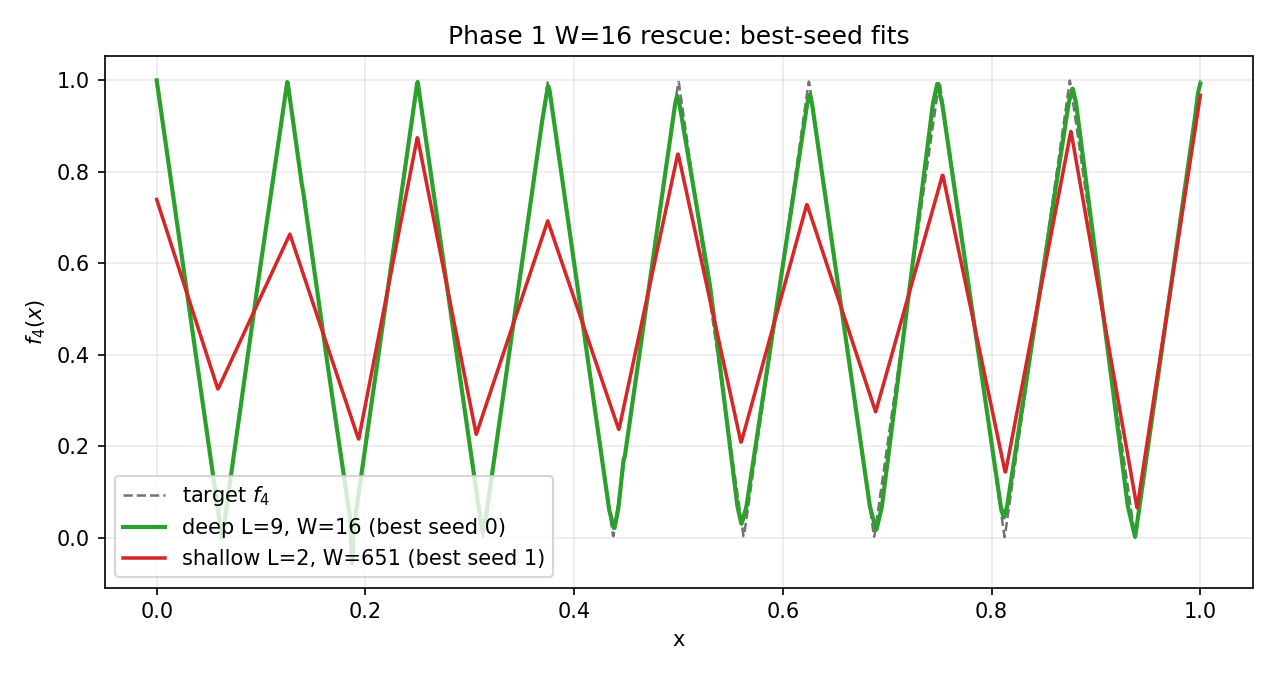

### phase2_input_noise.png

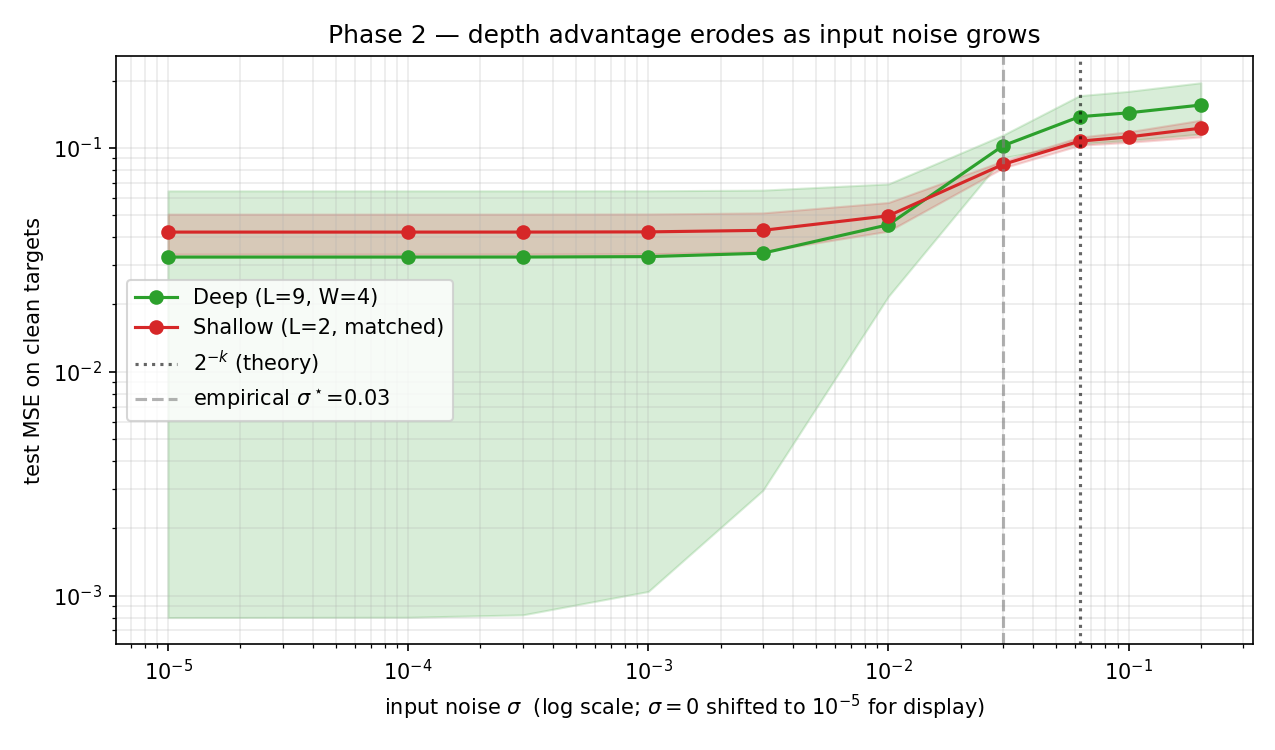

### phase3_gap.png

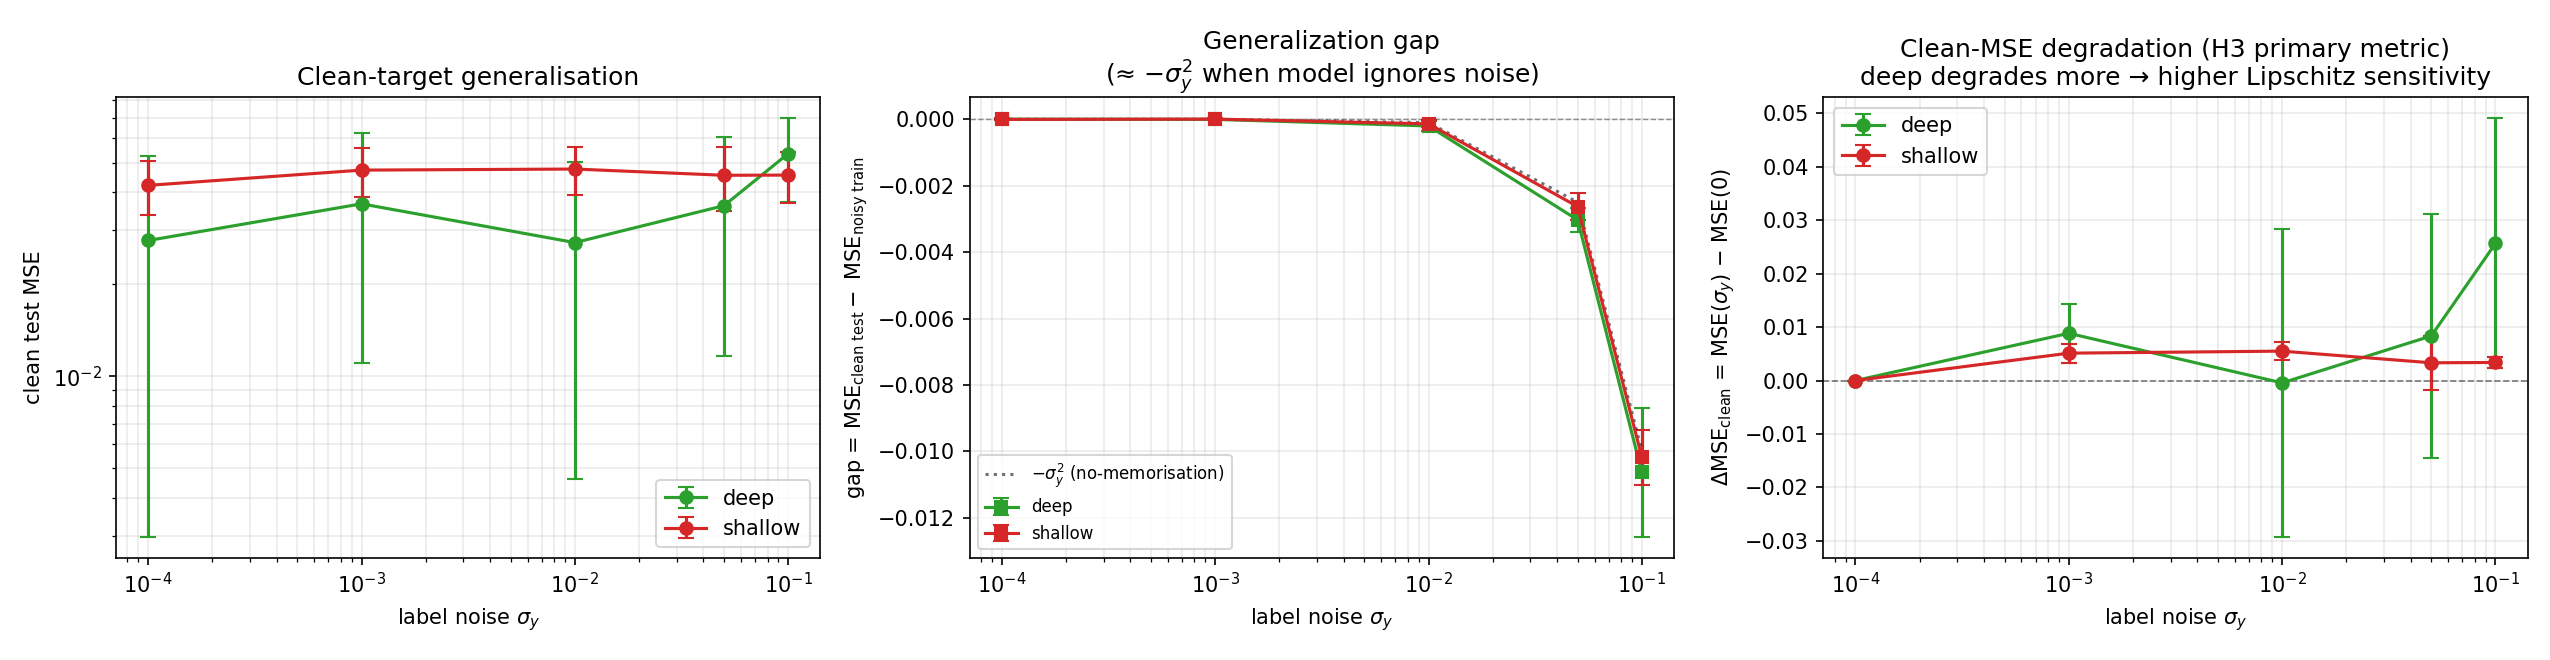

### phase4_adversarial.png

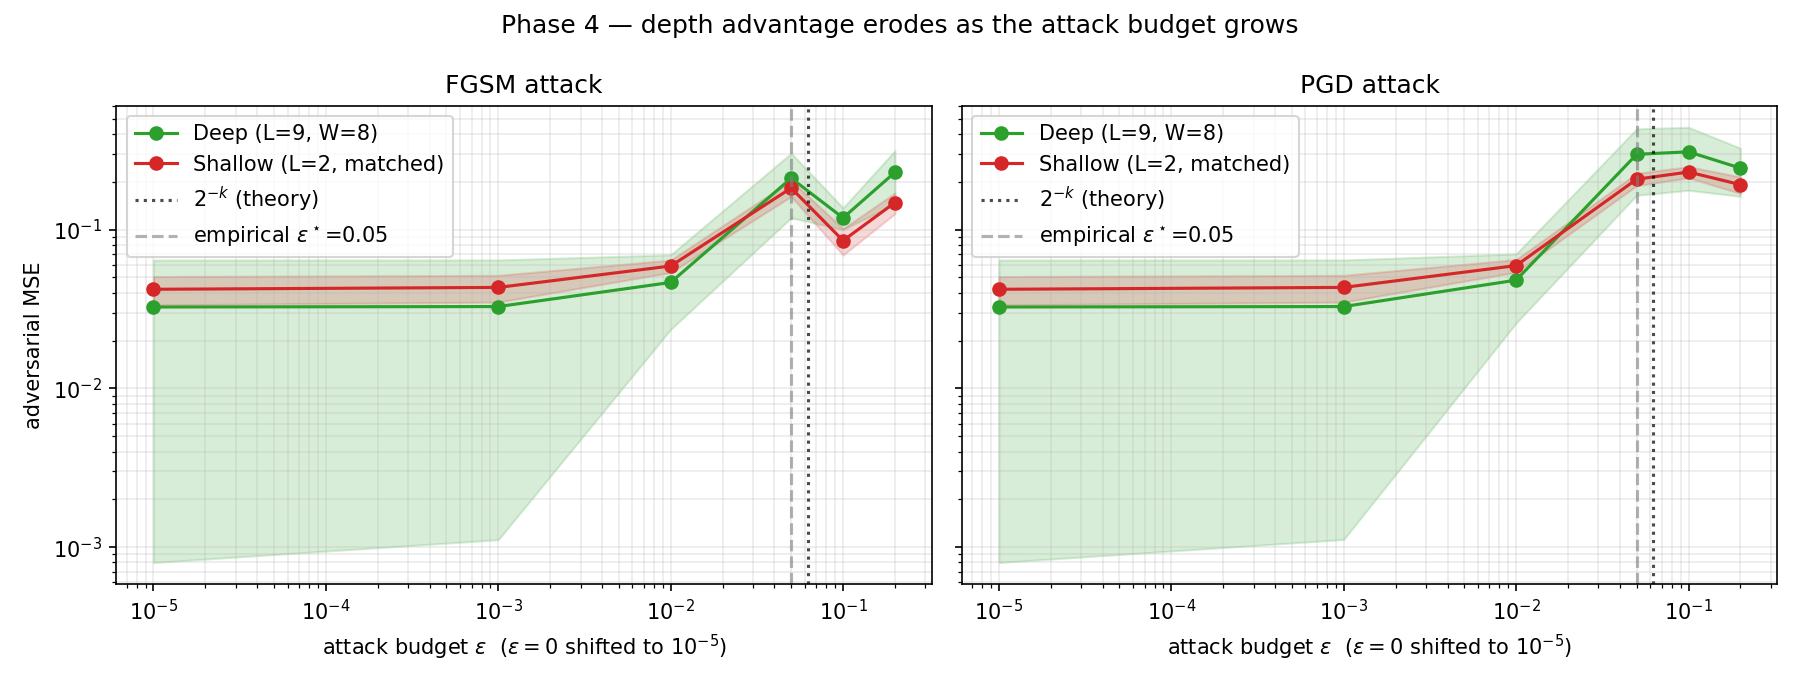

### phase5_lipschitz_regions.png

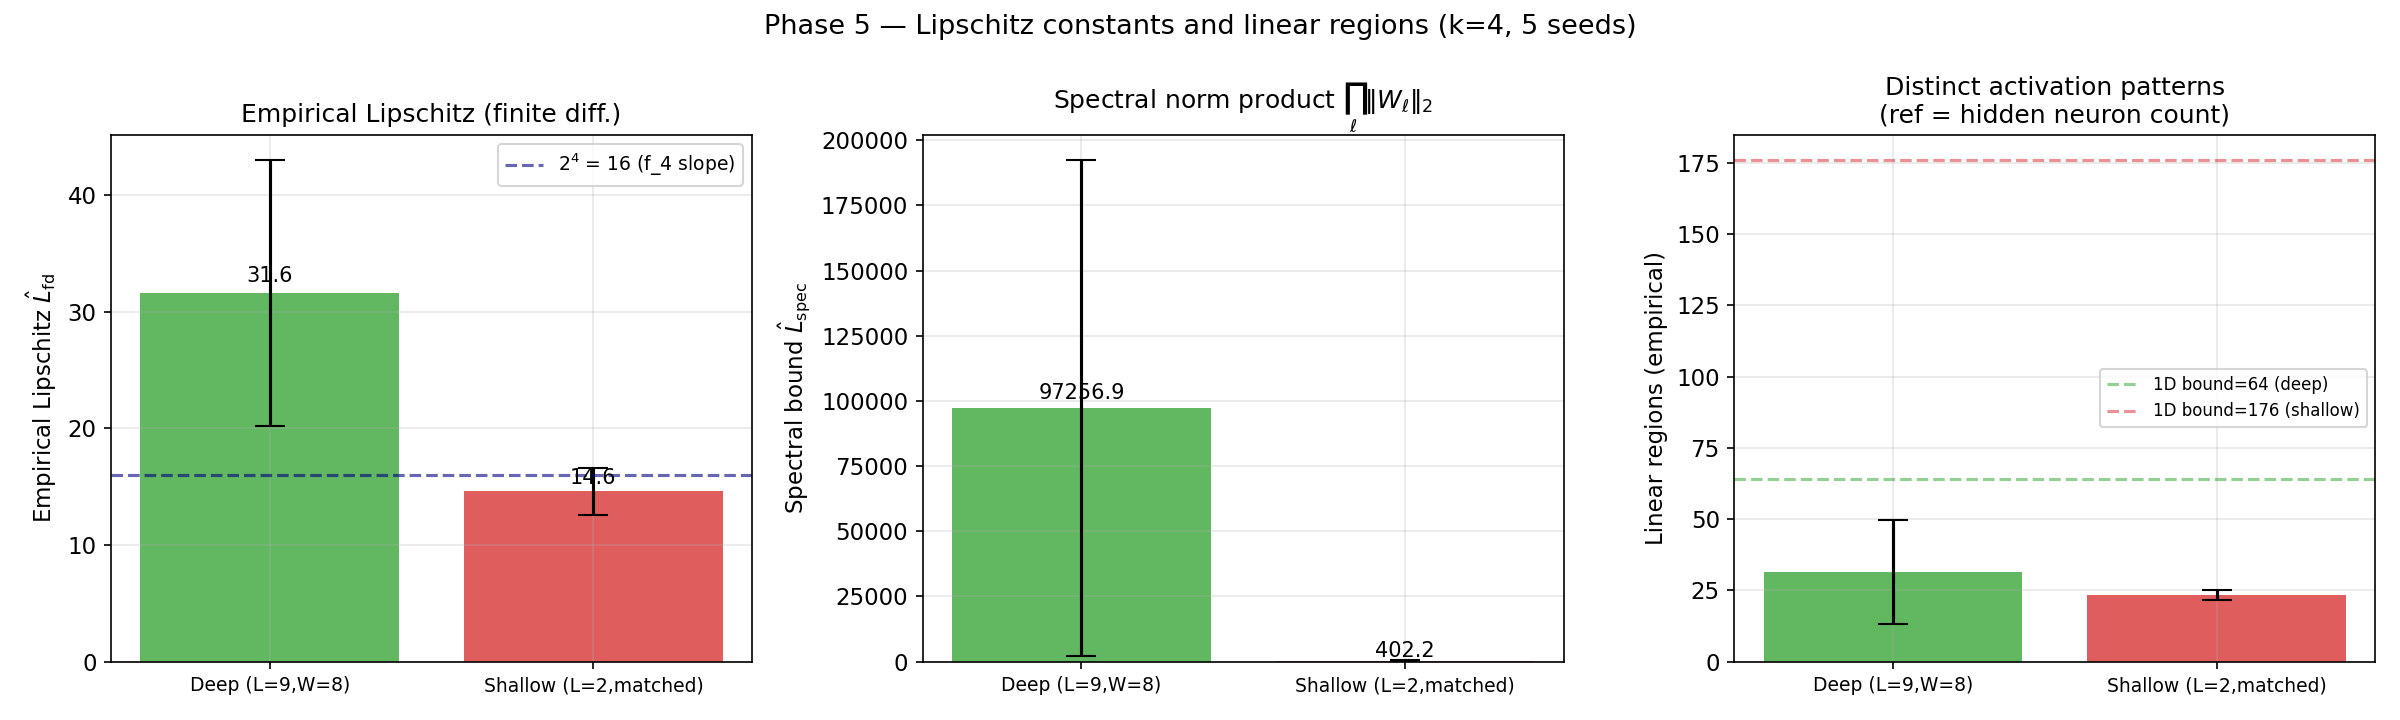

### phase6_scaling.png

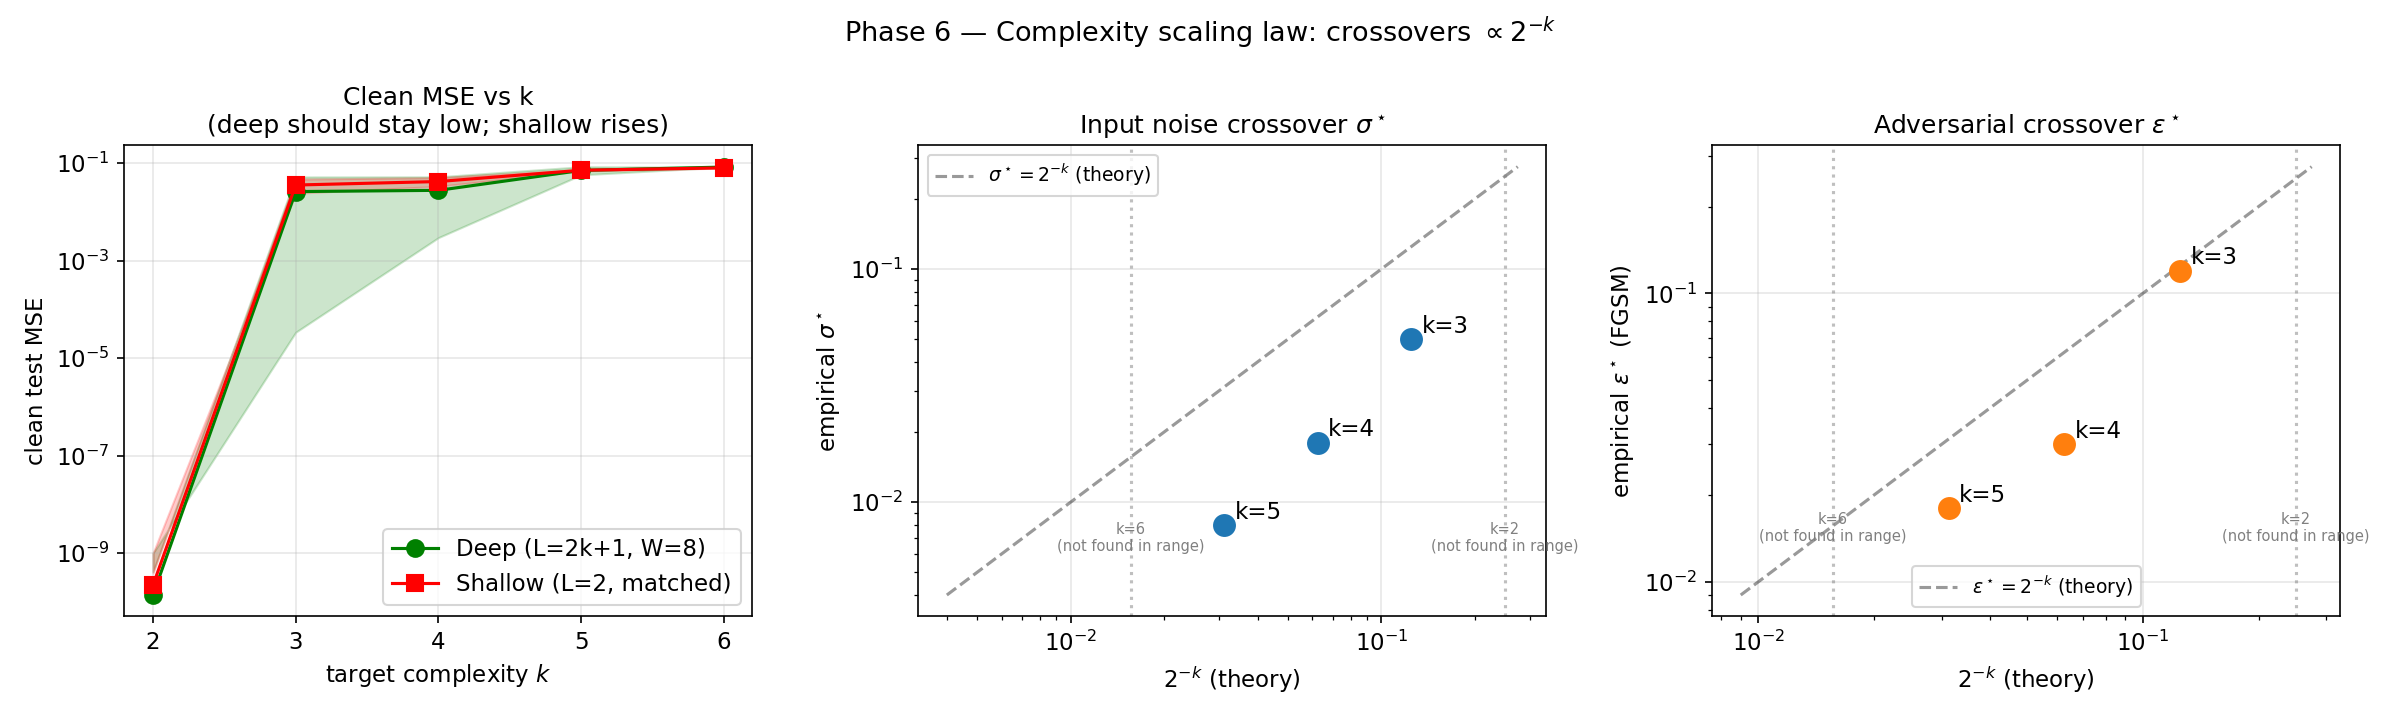

In [6]:
figure_files = [
    "phase1_w16_rescue_fits.png",
    "phase2_input_noise.png",
    "phase3_gap.png",
    "phase4_adversarial.png",
    "phase5_lipschitz_regions.png",
    "phase6_scaling.png",
]

for name in figure_files:
    path = FIGURE_DIR / name
    display(Markdown(f"### {name}"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("missing", path)


## 6. Direct Phase Links

- `notebooks/phase1_baseline.ipynb`
- `notebooks/phase2_input_noise.ipynb`
- `notebooks/phase3_label_noise.ipynb`
- `notebooks/phase4_adversarial.ipynb`
- `notebooks/phase5_lipschitz_regions.ipynb`
- `notebooks/phase6_complexity_scaling.ipynb`
